In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
from src.final_model import (
    evaluate_classification_model,
    fit_final_model,
    get_misclassified_examples,
    make_classification_report,
    make_confusion_matrix,
    make_prediction_results,
    plot_confusion_matrix,
    plot_probability_distribution,
    predict_final_model,
    predict_final_probabilities,
)
from sklearn.model_selection import train_test_split
import pandas as pd
from src.consts import (
    RANDOM_STATE,
    TARGET,
    DATA_PATH,
    TEST_SIZE,
    N_JOBS
)

In [8]:
df = pd.read_csv(DATA_PATH)

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [9]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((39073, 14), (9769, 14), (39073,), (9769,))

In [12]:
y_train.value_counts(normalize=True)

income
<=50K    0.76073
>50K     0.23927
Name: proportion, dtype: float64

In [13]:
y_test.value_counts(normalize=True)

income
<=50K    0.760672
>50K     0.239328
Name: proportion, dtype: float64

In [14]:
final_model = fit_final_model(
    X_train=X_train,
    y_train=y_train,
)

In [15]:
y_pred = predict_final_model(
    model=final_model,
    X_test=X_test,
)

y_proba = predict_final_probabilities(
    model=final_model,
    X_test=X_test,
    positive_class=">50K",
)

In [16]:
final_metrics = evaluate_classification_model(
    y_true=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
)

final_metrics

{'accuracy': 0.8720442215170437,
 'precision_macro': 0.8436161990880284,
 'recall_macro': 0.7866161097264495,
 'f1_macro': 0.8091840488818861,
 'roc_auc': 0.9252352610656189}

In [17]:
print(
    make_classification_report(
        y_true=y_test,
        y_pred=y_pred,
    )
)

              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      7431
        >50K       0.80      0.62      0.70      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.79      0.81      9769
weighted avg       0.87      0.87      0.87      9769



In [18]:
cm = make_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
)

cm

array([[7063,  368],
       [ 882, 1456]])

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Confusion matrix'}, xlabel='Predicted label', ylabel='True label'>)

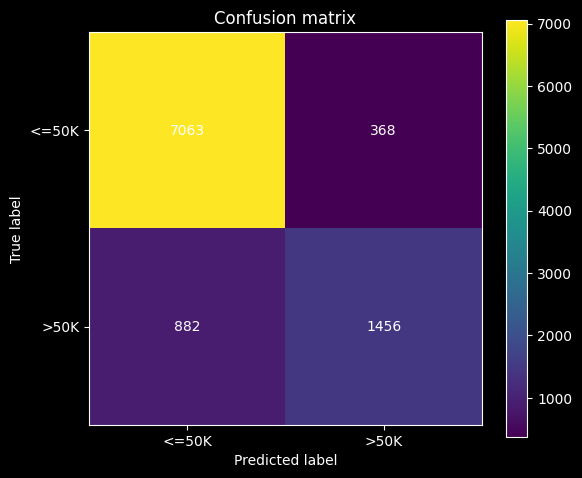

In [19]:
plot_confusion_matrix(
    cm=cm,
    labels=["<=50K", ">50K"],
)

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Predicted probability distribution'}, xlabel='Predicted probability of >50K', ylabel='Count'>)

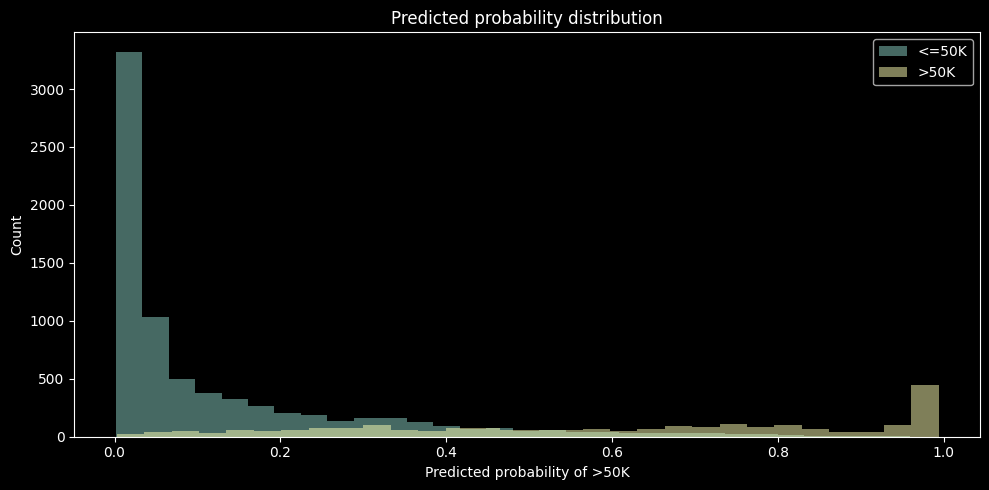

In [20]:
plot_probability_distribution(
    y_true=y_test,
    y_proba=y_proba,
    positive_class=">50K",
)

In [21]:
prediction_results = make_prediction_results(
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
)

prediction_results.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,actual_income,predicted_income,predicted_probability_positive,is_correct
40342,54,Private,115602,HS-grad,9,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,40,United-States,<=50K,<=50K,0.183736,True
47680,28,Local-gov,401886,HS-grad,9,Never-married,Adm-clerical,Other-relative,White,Male,0,0,20,United-States,<=50K,<=50K,0.009973,True
524,53,Local-gov,139671,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,<=50K,>50K,0.664400,False
8508,58,Private,177368,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,3137,0,16,United-States,<=50K,<=50K,0.053691,True
31692,47,Local-gov,352614,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,>50K,0.679114,True


In [22]:
get_misclassified_examples(
    prediction_results=prediction_results,
    top_n=10,
)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,actual_income,predicted_income,predicted_probability_positive,is_correct
45268,57,Private,64960,Assoc-voc,11,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,1902,45,United-States,<=50K,>50K,0.959474,False
23260,63,Private,108097,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,10566,0,45,United-States,<=50K,>50K,0.956459,False
4143,64,Private,159715,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,10566,0,40,United-States,<=50K,>50K,0.946237,False
33405,45,Private,120724,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,4386,0,40,United-States,<=50K,>50K,0.927176,False
3048,43,Federal-gov,190020,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,<=50K,>50K,0.924221,False
11265,38,Private,99783,Assoc-voc,11,Married-civ-spouse,Other-service,Wife,White,Female,0,1902,40,United-States,<=50K,>50K,0.882397,False
33169,40,Self-emp-not-inc,167081,Masters,14,Married-civ-spouse,Sales,Husband,White,Male,3103,0,50,United-States,<=50K,>50K,0.870797,False
2247,55,Self-emp-inc,304695,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,55,United-States,<=50K,>50K,0.865919,False
26916,36,Federal-gov,184556,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,>50K,0.858847,False
30182,55,Self-emp-inc,222615,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,<=50K,>50K,0.858075,False
